In [1]:

import os

# Pick physical GPU 2 before importing torch in this kernel session.
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from tqdm import tqdm

from glp.denoiser import load_glp
from glp import flow_matching, script_eval, script_steer
from glp.utils_acts import save_acts
from gemma2_pipeline.loading import iter_fineweb_texts, load_model_and_tokenizer
from gemma2_pipeline.preprocess import batch_items
from gemma2_pipeline.settings import FineWebSourceConfig

/mnt/disk2/envs/glp/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:

import torch

print("CUDA_VISIBLE_DEVICES:", os.environ.get("CUDA_VISIBLE_DEVICES"))
print("Visible logical GPUs:", torch.cuda.device_count())
if torch.cuda.is_available():
    print("Logical cuda:0:", torch.cuda.get_device_name(0))

CUDA_VISIBLE_DEVICES: 0
Visible logical GPUs: 1
Logical cuda:0: NVIDIA A30


**Load the GLP**

You can just put the HuggingFace repo and the checkpoint will be automatically downloaded for you.

In [27]:
# With CUDA_VISIBLE_DEVICES=2, physical GPU 2 is remapped to logical cuda:0.
device = "cuda:0"

# Your Gemma GLP checkpoint (local folder or HF repo id).
glp_name = "PQPQPQHUST/glp-gpt2"
glp_ckpt = "300M/spec_iqr"

# Gemma LLM setup for streaming reference activations and steering.
hf_model_name = "openai-community/gpt2"
hf_layer = 6

In [28]:
import time

t0 = time.time()
try:
    model, mean, var = load_glp(glp_name, device=device, checkpoint=glp_ckpt, local_files_only=True)
    print("Loaded GLP from local cache.")
except Exception as cache_err:
    print(f"Local cache miss ({type(cache_err).__name__}), falling back to online download.")
    model, mean, var = load_glp(glp_name, device=device, checkpoint=glp_ckpt, local_files_only=False)
model = model.to(torch.bfloat16)
embedding_dim = model.denoiser.model.d_input
print(f"GLP loaded in {time.time() - t0:.1f}s | embedding_dim={embedding_dim}")
print(f"Normalizer method: {getattr(model.normalizer, 'normalization_method', 'gaussian')}")

Local cache miss (FileNotFoundError), falling back to online download.


Fetching 0 files: 0it [00:00, ?it/s]


FileNotFoundError: [Errno 2] No such file or directory: '/home/aiotlab/.cache/huggingface/hub/models--PQPQPQHUST--glp-gpt2/snapshots/9e1876563c64cd22aefce41a8a23194c5bf40d39/config.yaml'

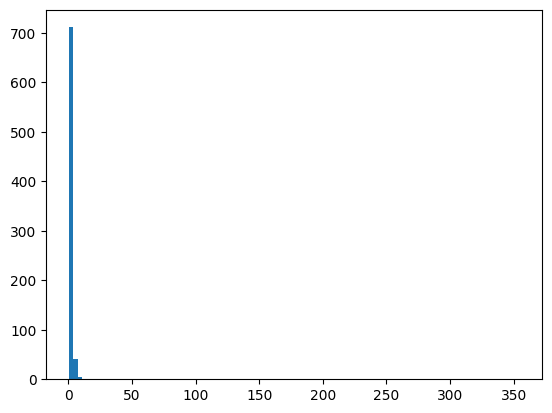

In [5]:
plt.hist(var.cpu().numpy(), bins=100)
plt.show()

**Checking GLP Quality**

Now that we've loaded up the model, we can sanity check that it's working by generating some activations.

In [6]:
def generate_activations(num_timesteps, batch_size, generator=None):
    print("Generating activations...")
    noise = torch.randn(batch_size, 1, embedding_dim, generator=generator).to(device)
    gen_latents = flow_matching.sample(model, noise, num_timesteps=num_timesteps)
    # map normalized latents back to activation space (gaussian or log_norm inverse)
    gen_latents = model.normalizer.denormalize(gen_latents)
    return gen_latents


def stream_reference_activations(
    hf_model,
    hf_tokenizer,
    layer,
    num_vectors=20000,
    dataset_name="HuggingFaceFW/fineweb",
    dataset_config="sample-10BT",
    split="train",
    text_field="text",
    max_documents=None,
    document_batch_size=16,
    forward_batch_size=1,
    max_length=1024,
    drop_bos=True,
):
    tracedict_config = {
        "layer_prefix": "transformer.h",
        "layers": [layer],
        "retain": "output",
    }
    fineweb_cfg = FineWebSourceConfig(
        dataset_name=dataset_name,
        dataset_config=dataset_config,
        split=split,
        text_field=text_field,
        streaming=True,
        max_documents=max_documents,
    )

    text_iter = iter_fineweb_texts(fineweb_cfg)
    chunks = []
    vectors_written = 0
    for text_batch in tqdm(
        batch_items(text_iter, document_batch_size),
        desc="Streaming FineWeb acts",
        dynamic_ncols=True,
    ):
        acts = save_acts(
            hf_model=hf_model,
            hf_tokenizer=hf_tokenizer,
            text=text_batch,
            tracedict_config=tracedict_config,
            padding_side="right",
            token_idx="all",
            batch_size=forward_batch_size,
            max_length=max_length,
        )
        vecs = acts[:, 0, :, :]
        if drop_bos and vecs.shape[1] > 1:
            vecs = vecs[:, 1:, :]
        vecs = vecs.reshape(-1, vecs.shape[-1])
        if vecs.shape[0] == 0:
            continue

        remaining = num_vectors - vectors_written
        vecs = vecs[:remaining]
        chunks.append(vecs.cpu())
        vectors_written += vecs.shape[0]
        if vectors_written >= num_vectors:
            break

    if vectors_written == 0:
        raise RuntimeError("No reference activations were collected from FineWeb streaming.")

    ref_latents = torch.cat(chunks, dim=0)[:, None, :]
    print(f"Collected {ref_latents.shape[0]} streamed reference vectors.")
    return ref_latents



def compute_fd(ref_latents, gen_latents):
    ref_vecs = ref_latents[:, 0, :].detach().cpu().float()
    gen_vecs = gen_latents[:, 0, :].detach().cpu().float()
    # ref_vecs = (ref_vecs - mean.cpu()) / torch.sqrt(var.cpu() + 1e-8)
    # gen_vecs = (gen_vecs - mean.cpu()) / torch.sqrt(var.cpu() + 1e-8)
    n = min(ref_vecs.shape[0], gen_vecs.shape[0])
    if n < 2:
        raise ValueError("Need at least 2 vectors per set to compute Frechet Distance.")
    return script_eval.rep_fd(ref_vecs[:n].float().numpy(), gen_vecs[:n].float().numpy())


def plot_pca(num_timesteps, batch_size, ref_latents, gen_latents):
    gen_latents = gen_latents[:, 0, :].detach().cpu()
    ref_latents = ref_latents[:, 0, :].detach().cpu()
    gen_latents = gen_latents[:batch_size, :]
    ref_latents = ref_latents[:batch_size, :]
    title = f"Num Timesteps: {num_timesteps}"
    print("Plotting PCA...")
    return script_eval.plot_pca(
        ref_latents,
        gen_latents,
        label_X="Real",
        label_Y="Generated",
        title=title,
        alpha=0.8,
        half_mask=num_timesteps >= 10,
    )

In [23]:
from pathlib import Path

ref_num_vectors = 50000
ref_cache = Path(f"data/frechet-stream-{hf_model_name.split('/')[-1]}-layer{hf_layer}-{ref_num_vectors}.pt")

if ref_cache.exists():
    print(f"Loading cached streamed reference activations from {ref_cache}")
    ref_latents = torch.load(ref_cache)["activations"]
else:
    print("Loading Gemma model for streaming references...")
    hf_model, hf_tokenizer = load_model_and_tokenizer(
        model_name=hf_model_name,
        device=device,
        torch_dtype_name="bfloat16",
    )
    ref_latents = stream_reference_activations(
        hf_model=hf_model,
        hf_tokenizer=hf_tokenizer,
        layer=hf_layer,
        num_vectors=ref_num_vectors,
        dataset_name="HuggingFaceFW/fineweb",
        dataset_config="sample-10BT",
        split="train",
        text_field="text",
        document_batch_size=16,
        forward_batch_size=1,
        max_length=1024,
    ).float()
    ref_cache.parent.mkdir(parents=True, exist_ok=True)
    torch.save({"activations": ref_latents}, ref_cache)
    print(f"Saved streamed references to {ref_cache}")

Loading cached streamed reference activations from data/frechet-stream-gpt2-layer6-50000.pt


Below, you will see PCA plots and Frechet Distance scores against streamed FineWeb references.

- Low Frechet Distance means generated activations are closer to the real reference distribution.
- High Frechet Distance means generated activations are farther from the reference distribution.

If streaming is slow, reduce ref_num_vectors or max_length in the previous cell.

In [8]:
# Keep these evaluation hyperparameters aligned with glp_demo.ipynb
batch_size = 10000
eval_timesteps = [1, 20]
fd_eval_vectors = min(batch_size, ref_latents.shape[0])

Generating activations...


1it [00:00, 13.85it/s]

Plotting PCA...


Generating activations...


20it [00:01, 13.34it/s]


Plotting PCA...


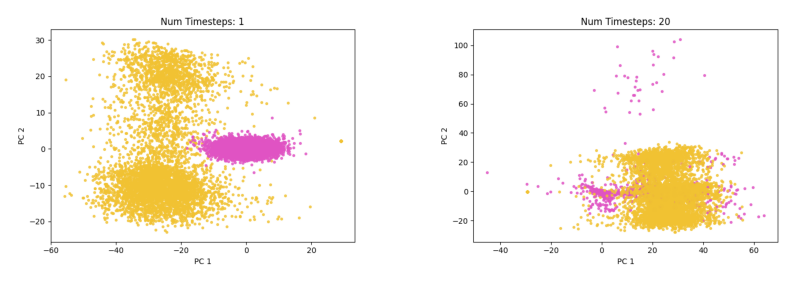

,frechet_distance
num_timesteps,
1,3484.50
20,3501.19


In [26]:
# run generation
generator = torch.Generator().manual_seed(42)
pca_plots = []
fd_rows = []
generated_latents_by_step = {}

for num_timesteps in eval_timesteps:
    gen_latents = generate_activations(num_timesteps, batch_size, generator=generator)
    generated_latents_by_step[num_timesteps] = gen_latents.detach().cpu()
    pca_plot = plot_pca(num_timesteps, batch_size, ref_latents, gen_latents)
    pca_plots.append(pca_plot)
    fd_rows.append({
        "num_timesteps": num_timesteps,
        "frechet_distance": compute_fd(ref_latents[:fd_eval_vectors], gen_latents[:fd_eval_vectors]),
    })

# visualize the PCA results
plt.figure(figsize=(5 * len(pca_plots), 5))
for i in range(len(pca_plots)):
    plt.subplot(1, len(pca_plots), i + 1)
    plt.imshow(pca_plots[i])
    plt.axis("off")
plt.show()

# show Frechet Distance summary
fd_df = pd.DataFrame(fd_rows).set_index("num_timesteps").sort_index()
fd_df.round(2)


**Distribution Evaluation: Fair Quality vs Raw-Dimension Attribution**

Frechet Distance is useful as a historical baseline, but it mixes scale, mean, covariance, and heavy-tail effects. For Gemma activations we use three separate diagnostics instead:

1. **Fair global quality:** robust Median/IQR scaling on raw activations, then global MMD with an IMQ kernel. This asks whether generated and reference distributions match after high-variance dimensions are put on a fair scale.
2. **Fair global sliced geometry:** robust Median/IQR scaling on raw activations, then sliced Wasserstein over random 1D projections. This asks whether joint cross-dimensional geometry matches under the same fair scale.
3. **Surgical attribution:** raw unnormalized activations, then independent 1D Wasserstein distance for each hidden dimension. This asks which dimensions are actually broken in raw activation space.

Keep the original full-covariance FD table above as a continuity baseline; use the metrics below for debugging and model selection.



In [10]:
def _activation_vectors(latents):
    """Return [n, d] activation vectors on CPU float32 from [n, 1, d] or [n, d]."""
    vecs = latents.detach().cpu().float()
    if vecs.ndim == 3:
        vecs = vecs[:, 0, :]
    if vecs.ndim != 2:
        raise ValueError(f"Expected [n, d] or [n, 1, d], got {tuple(vecs.shape)}")
    return vecs


def _align_samples(ref_latents, gen_latents, max_vectors=None):
    ref = _activation_vectors(ref_latents)
    gen = _activation_vectors(gen_latents)
    n = min(ref.shape[0], gen.shape[0])
    if max_vectors is not None:
        n = min(n, int(max_vectors))
    if n < 2:
        raise ValueError("Need at least 2 vectors per set.")
    return ref[:n].contiguous(), gen[:n].contiguous()


def fit_robust_iqr_scaler(ref_vecs, eps=1e-6):
    """Fit Median/IQR scaler on reference raw activations only."""
    median = ref_vecs.median(dim=0).values
    q25 = torch.quantile(ref_vecs, 0.25, dim=0)
    q75 = torch.quantile(ref_vecs, 0.75, dim=0)
    iqr = (q75 - q25).clamp_min(eps)
    return median, iqr


def apply_robust_iqr_scaler(vecs, median, iqr, clip=None):
    scaled = (vecs - median) / iqr
    clip_rate = (vecs.abs() > clip).float().mean().item()
    print(f"Warning: {clip_rate * 100:.2f}% of data was clipped.")
    if clip is not None:
        scaled = scaled.clamp(min=-float(clip), max=float(clip))
    return scaled


def _imq_kernel_sum(x, y, constants, chunk_size=512, exclude_diag=False):
    """Sum IMQ kernel values over all pairs without materializing the full matrix."""
    total = x.new_tensor(0.0)
    count = 0
    constants = torch.as_tensor(constants, device=x.device, dtype=x.dtype)

    for i in range(0, x.shape[0], chunk_size):
        xb = x[i:i + chunk_size]
        for j in range(0, y.shape[0], chunk_size):
            yb = y[j:j + chunk_size]
            dist2 = torch.cdist(xb, yb, p=2).pow(2)
            k = constants[:, None, None] / (constants[:, None, None] + dist2[None, :, :])
            k = k.mean(dim=0)
            if exclude_diag and x.data_ptr() == y.data_ptr() and i == j:
                diag_n = min(k.shape[0], k.shape[1])
                diag_idx = torch.arange(diag_n, device=k.device)
                k = k.clone()
                k[diag_idx, diag_idx] = 0.0
                count += k.numel() - diag_n
            else:
                count += k.numel()
            total = total + k.sum()
    return total, count


def imq_mmd2(x, y, constants=None, chunk_size=512, unbiased=True):
    """Global MMD^2 with an IMQ kernel. Lower is better; 0 means identical distributions."""
    if x.shape[1] != y.shape[1]:
        raise ValueError(f"Dim mismatch: {x.shape[1]} vs {y.shape[1]}")
    d = x.shape[1]
    if constants is None:
        constants = [0.1 * d, 0.2 * d, 0.5 * d, 1.0 * d, 2.0 * d, 5.0 * d, 10.0 * d]

    xx_sum, xx_count = _imq_kernel_sum(x, x, constants, chunk_size=chunk_size, exclude_diag=unbiased)
    yy_sum, yy_count = _imq_kernel_sum(y, y, constants, chunk_size=chunk_size, exclude_diag=unbiased)
    xy_sum, xy_count = _imq_kernel_sum(x, y, constants, chunk_size=chunk_size, exclude_diag=False)

    mmd2 = xx_sum / xx_count + yy_sum / yy_count - 2.0 * xy_sum / xy_count
    return mmd2.clamp_min(0.0)


def fair_imq_mmd(ref_latents, gen_latents, max_vectors=2048, iqr_clip=20.0, chunk_size=512):
    """Fair global quality score: raw activations -> reference IQR scale -> IMQ MMD."""
    ref_raw, gen_raw = _align_samples(ref_latents, gen_latents, max_vectors=max_vectors)
    median, iqr = fit_robust_iqr_scaler(ref_raw)
    ref_scaled = apply_robust_iqr_scaler(ref_raw, median, iqr, clip=iqr_clip)
    gen_scaled = apply_robust_iqr_scaler(gen_raw, median, iqr, clip=iqr_clip)
    mmd2 = imq_mmd2(ref_scaled, gen_scaled, chunk_size=chunk_size, unbiased=True)
    return {
        "mmd2_imq_iqr": float(mmd2.item()),
        "mmd_imq_iqr": float(torch.sqrt(mmd2).item()),
        "num_vectors": int(ref_scaled.shape[0]),
        "iqr_clip": iqr_clip,
    }


def sliced_wasserstein_distance(ref_vecs, gen_vecs, num_projections=2000, seed=0):
    """Global sliced W1 over random 1D projections. Lower is better."""
    if ref_vecs.ndim != 2 or gen_vecs.ndim != 2:
        raise ValueError("Expected [num_vectors, dim] tensors.")
    if ref_vecs.shape != gen_vecs.shape:
        raise ValueError(f"Shape mismatch: {tuple(ref_vecs.shape)} vs {tuple(gen_vecs.shape)}")

    with torch.no_grad():
        ref = ref_vecs.float()
        gen = gen_vecs.float()
        _, dim = ref.shape

        generator = torch.Generator(device=ref.device)
        generator.manual_seed(int(seed))
        directions = torch.randn(
            dim,
            int(num_projections),
            device=ref.device,
            dtype=ref.dtype,
            generator=generator,
        )
        directions = directions / directions.norm(dim=0, keepdim=True).clamp_min(torch.finfo(ref.dtype).eps)

        proj_ref = ref @ directions
        proj_gen = gen @ directions
        ref_sorted = proj_ref.sort(dim=0).values
        gen_sorted = proj_gen.sort(dim=0).values
        return (ref_sorted - gen_sorted).abs().mean()


def fair_sliced_wasserstein(ref_latents, gen_latents, max_vectors=2048, iqr_clip=20.0, num_projections=2000, seed=0):
    """Fair global quality score: raw activations -> reference IQR scale -> sliced W1."""
    ref_raw, gen_raw = _align_samples(ref_latents, gen_latents, max_vectors=max_vectors)
    median, iqr = fit_robust_iqr_scaler(ref_raw)
    ref_scaled = apply_robust_iqr_scaler(ref_raw, median, iqr, clip=iqr_clip)
    gen_scaled = apply_robust_iqr_scaler(gen_raw, median, iqr, clip=iqr_clip)
    swd = sliced_wasserstein_distance(
        ref_scaled,
        gen_scaled,
        num_projections=num_projections,
        seed=seed,
    )
    return {
        "swd_iqr": float(swd.item()),
        "num_vectors": int(ref_scaled.shape[0]),
        "iqr_clip": iqr_clip,
        "num_projections": int(num_projections),
        "projection_seed": int(seed),
    }


def wasserstein_1d_per_dim(ref_latents, gen_latents, max_vectors=None):
    """Raw attribution score: exact 1D W1 for each dim using equal sample counts."""
    ref_raw, gen_raw = _align_samples(ref_latents, gen_latents, max_vectors=max_vectors)
    ref_sorted = ref_raw.sort(dim=0).values
    gen_sorted = gen_raw.sort(dim=0).values
    w1 = (ref_sorted - gen_sorted).abs().mean(dim=0)

    ref_mean = ref_raw.mean(dim=0)
    gen_mean = gen_raw.mean(dim=0)
    ref_var = ref_raw.var(dim=0, unbiased=False)
    gen_var = gen_raw.var(dim=0, unbiased=False)
    glp_var = var.detach().cpu().float().reshape(-1)

    df = pd.DataFrame({
        "dim": np.arange(ref_raw.shape[1]),
        "wasserstein_1d_raw": w1.numpy(),
        "ref_mean_raw": ref_mean.numpy(),
        "gen_mean_raw": gen_mean.numpy(),
        "mean_abs_error_raw": (gen_mean - ref_mean).abs().numpy(),
        "ref_var_raw": ref_var.numpy(),
        "gen_var_raw": gen_var.numpy(),
        "var_abs_error_raw": (gen_var - ref_var).abs().numpy(),
        "glp_var": glp_var.numpy(),
    })
    df["glp_var_rank"] = df["glp_var"].rank(method="min", ascending=False).astype(int)
    df["wasserstein_rank"] = df["wasserstein_1d_raw"].rank(method="min", ascending=False).astype(int)
    return df.sort_values("wasserstein_1d_raw", ascending=False).reset_index(drop=True)


def plot_raw_wasserstein_attribution(wass_df, top_k=20):
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.scatter(wass_df["glp_var"], wass_df["wasserstein_1d_raw"], s=10, alpha=0.35)
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel("GLP raw variance")
    ax.set_ylabel("Raw 1D Wasserstein distance")
    ax.set_title("Raw per-dimension attribution")
    for _, row in wass_df.head(top_k).iterrows():
        ax.annotate(int(row["dim"]), (row["glp_var"], row["wasserstein_1d_raw"]), fontsize=8)
    plt.tight_layout()
    plt.show()



Evaluation timestep: 20
Fair global quality: Robust IQR -> IMQ MMD


,mmd2_imq_iqr,mmd_imq_iqr,num_vectors,iqr_clip
0,0.001887,0.043443,2048,30.0



Fair global quality: Robust IQR -> sliced Wasserstein


,swd_iqr,num_vectors,iqr_clip,num_projections,projection_seed
0,0.151302,2048,30.0,2000,0



Raw attribution: top 20 dimensions by 1D Wasserstein
Top-20 W1 dims that are also top-50 GLP variance dims: 18/20


,dim,wasserstein_1d_raw,wasserstein_rank,glp_var_rank,glp_var,ref_var_raw,gen_var_raw,mean_abs_error_raw,var_abs_error_raw
0,447,5.0851,1,1,354.671814,359.838013,328.139099,5.0713,31.698900
1,266,3.7340,2,4,93.623398,73.857597,132.772705,3.7198,58.915100
2,373,2.9451,3,3,136.647003,140.908005,123.753998,2.8302,17.153999
3,480,2.9214,4,6,88.253899,90.500397,132.080597,2.3168,41.580200
4,87,2.6334,5,5,89.042801,95.427696,133.981003,2.5583,38.553299
5,481,2.6142,6,7,67.563797,71.600304,71.276802,2.5953,0.323500
6,393,2.0037,7,8,54.699600,53.891800,57.773701,1.9953,3.881900
7,326,1.7652,8,9,36.965000,36.229698,34.479900,1.7610,1.749700
8,314,1.1231,9,12,13.145800,13.553700,15.657800,1.1112,2.104100
9,64,1.0081,10,2,152.329407,158.312805,144.308594,0.2689,14.004200


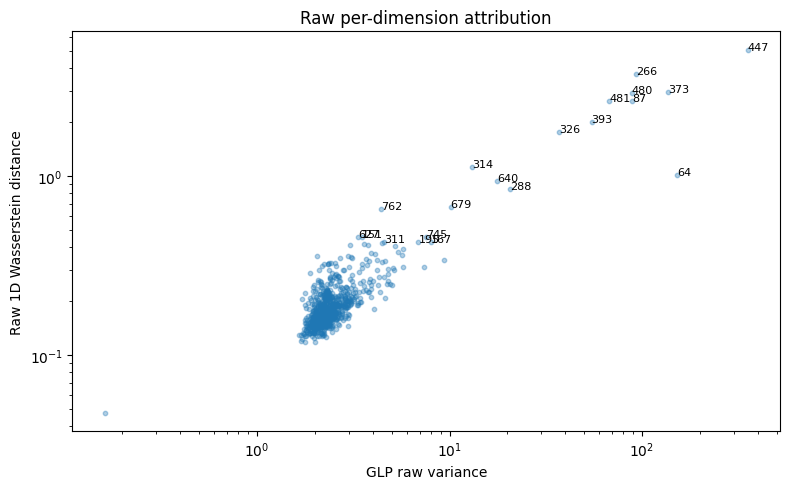

In [11]:
# Choose which generated distribution to evaluate.
eval_quality_timesteps = max(eval_timesteps)
eval_ref = ref_latents[:fd_eval_vectors]
eval_gen = generated_latents_by_step[eval_quality_timesteps][:fd_eval_vectors]

# MMD is O(n^2). Keep global metrics moderate; increase if you need lower-variance estimates.
global_metric_max_vectors = min(2048, fd_eval_vectors)
swd_num_projections = 2000
swd_seed = 0
wasserstein_max_vectors = fd_eval_vectors

fair_scores = fair_imq_mmd(
    eval_ref,
    eval_gen,
    max_vectors=global_metric_max_vectors,
    iqr_clip=30.0,
    chunk_size=512,
)

swd_scores = fair_sliced_wasserstein(
    eval_ref,
    eval_gen,
    max_vectors=global_metric_max_vectors,
    iqr_clip=30.0,
    num_projections=swd_num_projections,
    seed=swd_seed,
)

wass_df = wasserstein_1d_per_dim(
    eval_ref,
    eval_gen,
    max_vectors=wasserstein_max_vectors,
)

top_k = 20
top_wass = wass_df.head(top_k)
top_glp_dims = set(wass_df.sort_values("glp_var", ascending=False).head(50)["dim"])
top_wass_in_top_glp50 = top_wass["dim"].isin(top_glp_dims).sum()

print(f"Evaluation timestep: {eval_quality_timesteps}")
print("Fair global quality: Robust IQR -> IMQ MMD")
display(pd.DataFrame([fair_scores]))
print()
print("Fair global quality: Robust IQR -> sliced Wasserstein")
display(pd.DataFrame([swd_scores]))
print()
print(f"Raw attribution: top {top_k} dimensions by 1D Wasserstein")
print(f"Top-{top_k} W1 dims that are also top-50 GLP variance dims: {top_wass_in_top_glp50}/{top_k}")
display(top_wass[[
    "dim", "wasserstein_1d_raw", "wasserstein_rank", "glp_var_rank",
    "glp_var", "ref_var_raw", "gen_var_raw", "mean_abs_error_raw", "var_abs_error_raw",
]].round(4))

plot_raw_wasserstein_attribution(wass_df, top_k=top_k)



**On-Manifold Steering with GLP (Gemma-2-2B-it)**

Here we use a pre-computed Gemma steering vector and compare:
- normal generation
- steer only
- steer + GLP post-processing

In [12]:
# If streaming references already loaded Gemma, reuse it.
if "hf_model" not in globals() or "hf_tokenizer" not in globals():
    hf_model, hf_tokenizer = load_model_and_tokenizer(
        model_name=hf_model_name,
        device=device,
        torch_dtype_name="bfloat16",
    )
else:
    hf_model.to(torch.bfloat16)
    hf_model.eval()
    print("Reusing existing Gemma model/tokenizer from earlier cells.")

if hf_tokenizer.pad_token is None and hf_tokenizer.eos_token is not None:
    hf_tokenizer.pad_token = hf_tokenizer.eos_token
if getattr(hf_model.config, "pad_token_id", None) is None and hf_tokenizer.pad_token_id is not None:
    hf_model.config.pad_token_id = hf_tokenizer.pad_token_id
if getattr(hf_model, "generation_config", None) is not None and hf_model.generation_config.pad_token_id is None:
    hf_model.generation_config.pad_token_id = hf_tokenizer.pad_token_id

import importlib
script_steer = importlib.reload(script_steer)

In [13]:
question = "The boy heard the question and said: "

seed = 42
max_new_tokens = 80
temperature = 0.5
alphas = torch.tensor([0, 1, 2, 3, 5, 7, 10], dtype=torch.bfloat16)

vector_path = "Vector/CAA/extracted/GPT2/refuse/vector.pt"
glp_u = 0.7
glp_num_timesteps = 50

In [14]:
layer_name = f"transformer.h.{hf_layer}"

# Load one layer steering vector from a tensor or dict payload.
payload = torch.load(vector_path, map_location="cpu")
steer_vector = payload[hf_layer] if isinstance(payload, dict) else payload

if steer_vector is None:
    raise ValueError(f"Layer {hf_layer} not found in {vector_path}")
if steer_vector.ndim > 1:
    steer_vector = steer_vector.squeeze()
if steer_vector.ndim != 1:
    raise ValueError(f"Expected a 1D steering vector, got shape {tuple(steer_vector.shape)}")
steer_vector = steer_vector.to(device=hf_model.device, dtype=hf_model.dtype)
try:
    chat_prompt = hf_tokenizer.apply_chat_template(
        [{"role": "user", "content": question}],
        tokenize=False,
        add_generation_prompt=True,
    )
except:
    chat_prompt = question

settings = {
    "No Intervention": (None, None),
    "Steer Only": (script_steer.addition_intervention, None),
    "Steer + GLP": (
        script_steer.addition_intervention,
        script_steer.postprocess_on_manifold_wrapper(
            model,
            u=glp_u,
            num_timesteps=glp_num_timesteps,
            layer_idx=hf_layer,
        ),
    ),
}

results = {}
for setting, (intervention_wrapper, postprocess_fn) in settings.items():
    print(f"Running {setting}...")
    generate_with_intervention = script_steer.generate_with_intervention_wrapper(seed=seed)
    generate_kwargs = {
        "max_new_tokens": max_new_tokens,
        "do_sample": temperature > 0,
        "temperature": temperature,
        "pad_token_id": hf_tokenizer.eos_token_id,
    }

    if intervention_wrapper is None:
        gen_text = generate_with_intervention(
            [chat_prompt] * len(alphas),
            hf_model,
            hf_tokenizer,
            layers=[],
            intervention_wrapper=None,
            generate_kwargs=generate_kwargs,
        )
    else:
        gen_text = generate_with_intervention(
            [chat_prompt] * len(alphas),
            hf_model,
            hf_tokenizer,
            layers=[layer_name],
            intervention_wrapper=intervention_wrapper,
            intervention_kwargs={
                "w": steer_vector,
                "alphas": alphas.to(device=hf_model.device, dtype=hf_model.dtype),
                "postprocess_fn": postprocess_fn,
            },
            generate_kwargs=generate_kwargs,
        )
    results[setting] = gen_text

Running No Intervention...
Running Steer Only...
Running Steer + GLP...


In [15]:
# show results
pd.set_option('display.max_colwidth', None)
results_df = pd.DataFrame(results)
results_df.index = alphas.tolist()
results_df.columns = settings.keys()
results_df

,No Intervention,Steer Only,Steer + GLP
0.0,"""I don't know what happened. I don't know if it was a shot, or if it was a gunshot.""\nThe boy told the parents what happened and then said: ""I think he was killed by someone else.""\nThe boy said he had been playing with his father.\nThe boy said he was wearing a helmet and the boy said he heard the sound of a gunshot","""I don't know what happened. I don't know if it was a shot, or if it was a gunshot.""\nThe boy told the parents what happened and then said: ""I think he was killed by someone else.""\nThe boy said he had been playing with his father.\nThe boy said he was wearing a helmet and the boy said he heard the sound of a gunshot","""I don't think I can handle this.""\n The girl replied: ""You are so mad!"" and the boy answered: ""No, I don't think I can handle this.""\n The girl said: ""I am so mad."" and the boy replied: ""No, I am so mad.""\n The girl said:"
1.0,"""I don't think so. I don't think he's going to be a good kid.""\nA couple of days later, the boy was given a letter from the parents, signed by his mother. \nThe letter said: ""I am very happy to have you as my son. We are very sorry for the hurt that has been caused to your son. \n","""I don't think we'll be able to get the money back.""\n""I'm not going to give you a penny for the money,"" said the boy.\n""I don't know what the hell you're talking about,"" said the boy.\n""We'll have to wait for the police to bring it back,"" said the police officer.\nThe boy then tried to say","""I just want to see it. I just want to see it.""\n\nHis mother looked at him and said: ""I know you didn't know what happened to him. I just want to see it.""\n\nThe boy said: ""I can't believe you just showed up and told me what happened. You didn't understand. I just want to see"
2.0,"""Hello. I'm sorry, I'm sorry."" He then looked up and saw the child's face. He said: ""I'm sorry. I'm sorry."" He then looked up and saw the child's face. He then said: ""I'm sorry. I'm sorry."" He then looked up and saw the child's face.","""I'm going to drive right to the school."" When he said he was going to drive, the boy said he was going to drive. I wasn't going to drive.\nHe was driving.\nI wasn't going to drive.\nHe was going to drive.\nHe was going to drive.\nI didn't get the answer.\nI was going.\nI was","""Your father's a good man."" \nHis father was not. I guess the kid didn't realize he was talking about the man who died. I suppose the boy thought he was talking about the man who died.\nThe son was not.\n\nThe boy didn't.\n\nThe boy didn't.\n\nThe boy doesn't.\n\nThe boy doesn't."
3.0,"""I'm not sure it's true.""\nThis is a story about a boy who was bullied.\nThe boy is a young man from a small town.\nThe boy has a very shy voice.\nThe boy is a girl.\nThe boy is a girl.\nThe boy is a girl.\nThe boy is a girl.\nThe boy is a girl.\nThe","""I'm going to sit. I want to sit. I'll be. I don't want to sit. I want to sit.""\n\nI was.\n\n""It's not going to be. If you want to sit. It's going to be.""\n\nIt's not going to be.\n\n""I'm going to be. I'm going to sit.","""The guy."" I said. He said. I said. He said. I said. He said. I said. I said. He said. I said. I said. He said. I said. I said. I said. I said. He said. I said. I said. He said. I said. I said. I said. I said. I said."
5.0,"""I'm sorry, I just want to talk to you.""\nThe boy said: ""What?""\n""What do you mean?""\n""What did I just say?""\n""I'm sorry, I just want to talk to you.""\n""What do you mean?""\n""What did I just say?""\n""I'm sorry, I just want to talk to you.""","?""""He's a stupid idiot.\n""I. I.\n""You are a teacher. I. I. I. I. I. I. I. I. I. I. I. I. I. I. I. I. I. I. I. I. I. I. I. I. I. I. I. I. I. I","""I. ..."". ""I. .."". I. .... .. . . . . . . . . . . . . . . . . .. . . . . .. . . . . . . . . . . . . . . . . . . . . . . . . . . . . . ."
7.0,"""What about the girls? They're a bit weird, I'm not sure what the hell they're doing here."" \n ""Well, I'm not sure w